# Oasis Infobyte Internship

# Task 4: Sentiment Analysis Using Machine Learning

## Objective

The objective of this project is to build a machine learning model capable of classifying the sentiment of tweets. The project demonstrates Natural Language Processing (NLP) techniques including text preprocessing, TF-IDF feature extraction, and sentiment classification using machine learning algorithms.

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from wordcloud import WordCloud

plt.style.use("ggplot")

In [26]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [27]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\srilo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
df = pd.read_excel("twitter.xlsx")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [29]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()
df.duplicated().sum()

Shape: (31962, 3)
<class 'pandas.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      31962 non-null  int64
 1   label   31962 non-null  int64
 2   tweet   31961 non-null  str  
dtypes: int64(2), str(1)
memory usage: 749.2 KB


np.int64(0)

## Observation

- Dataset contains over 31,000 tweets.
- No missing values were found.
- The dataset contains tweet text and sentiment labels.

In [30]:
df["label"].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

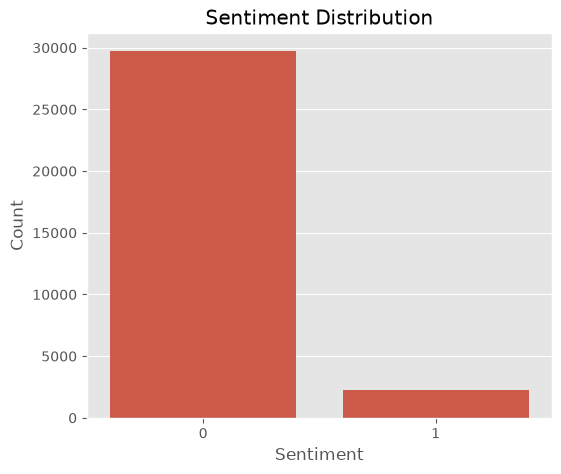

In [31]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="label")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Observation

The chart shows the distribution of sentiment classes in the dataset.
Understanding class balance is important before training machine learning models.

## Text Preprocessing

The tweets are cleaned using the following steps:

- Convert text to lowercase
- Remove URLs
- Remove usernames
- Remove punctuation
- Remove numbers
- Remove stopwords
- Perform lemmatization

These steps improve the quality of text data before feature extraction.

In [32]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [33]:
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove usernames
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags
    text = re.sub(r"#", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize using regex
    tokens = re.findall(r"\b[a-z]+\b", text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [34]:
df["clean_tweet"] = df["tweet"].apply(clean_text)

In [35]:
df[["tweet", "clean_tweet"]].head()

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cant use cause dont offer w...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,model love u take u time ur
4,factsguide: society now #motivation,factsguide society motivation


# Feature Extraction using TF-IDF

## What is TF-IDF?

TF-IDF (Term Frequency - Inverse Document Frequency) is a text vectorization technique that converts text into numerical features that machine learning models can understand.

### Why TF-IDF?

- Measures the importance of words in a document.
- Reduces the influence of common words.
- Gives higher weight to meaningful words.
- Creates numerical vectors for machine learning algorithms.

TF-IDF is widely used in Natural Language Processing (NLP) tasks such as sentiment analysis, spam detection, and document classification.

In [36]:
# Features (X) and Target (y)

X = df["clean_tweet"]
y = df["label"]

# TF-IDF Vectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (31962, 5000)


### Observation

The text data has been transformed into numerical feature vectors using TF-IDF.

Each row represents a tweet, while each column represents an important word selected by the vectorizer.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 25569
Testing Samples  : 6393


## Train-Test Split

The dataset is divided into:

- **80% Training Data** – Used for model learning.
- **20% Testing Data** – Used for evaluating model performance.

This helps measure how well the trained model performs on unseen data.

## Naive Bayes Classifier

In [38]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [39]:
print("Naive Bayes Accuracy")

print(accuracy_score(y_test, nb_pred))

print("\nClassification Report\n")

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy
0.9540122008446739

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5945
           1       0.91      0.38      0.54       448

    accuracy                           0.95      6393
   macro avg       0.93      0.69      0.76      6393
weighted avg       0.95      0.95      0.95      6393



## Logistic Regression Classifier

In [40]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [41]:
print("Logistic Regression Accuracy")

print(accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy
0.9516658845612389

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5945
           1       0.91      0.35      0.50       448

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.74      6393
weighted avg       0.95      0.95      0.94      6393



## Model Comparison

In [42]:
results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ]

})

results

,Model,Accuracy
0,Naive Bayes,0.954012
1,Logistic Regression,0.951666


## Accuracy Comparison Chart

C:\Users\srilo\AppData\Local\Temp\ipykernel_20296\2150147221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


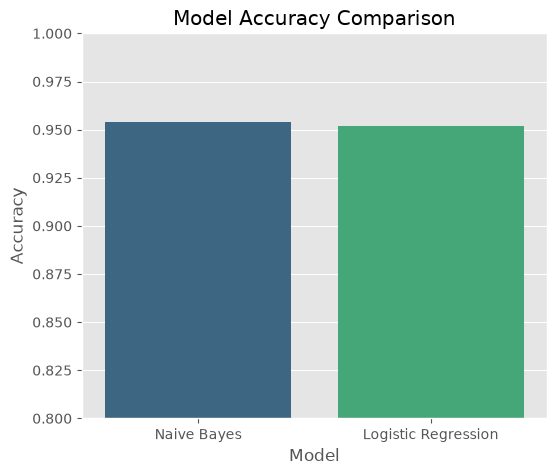

In [43]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.8,1)

plt.show()

### Observation

The comparison chart highlights the accuracy of both machine learning models.

The model with the highest accuracy will be selected as the final sentiment classifier.

## Confusion Matrix

## Naive Bayes

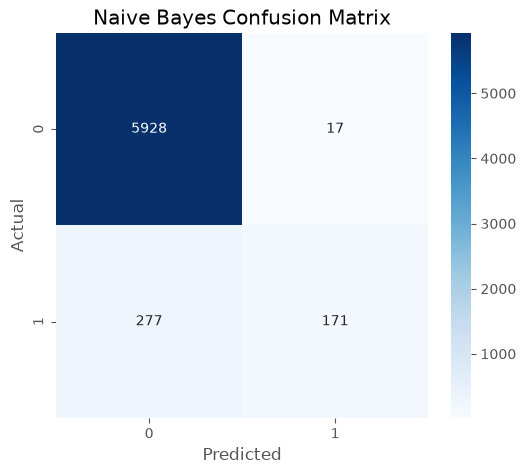

In [44]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Logistic Regression

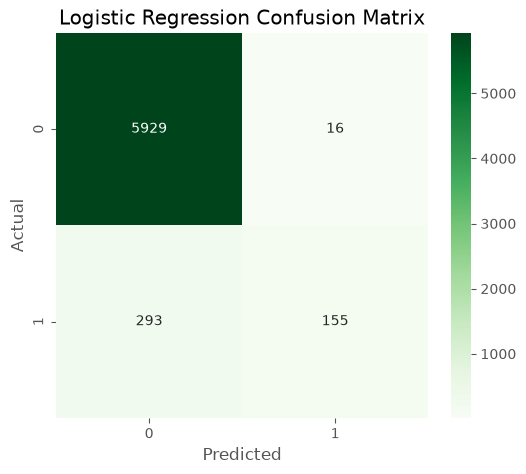

In [45]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Observation

The confusion matrix shows the number of correctly and incorrectly classified tweets.

Higher values along the diagonal indicate better model performance.

## Negative Tweets (label == 0)

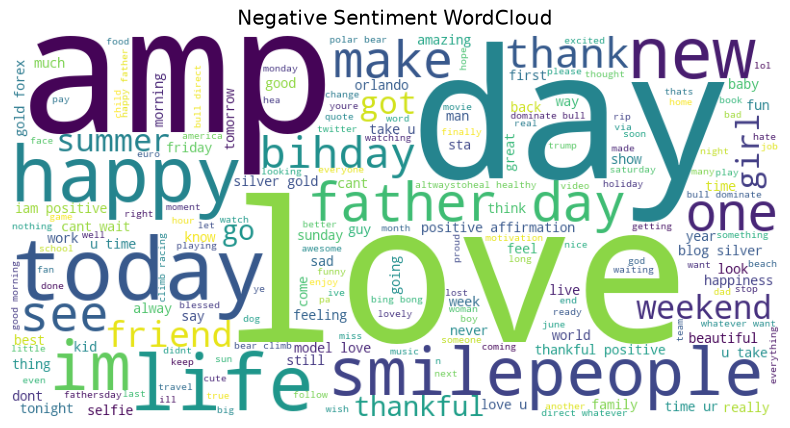

In [46]:
negative_text = " ".join(df[df["label"]==0]["clean_tweet"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Sentiment WordCloud")

plt.show()

## Positive Tweets (label == 1)

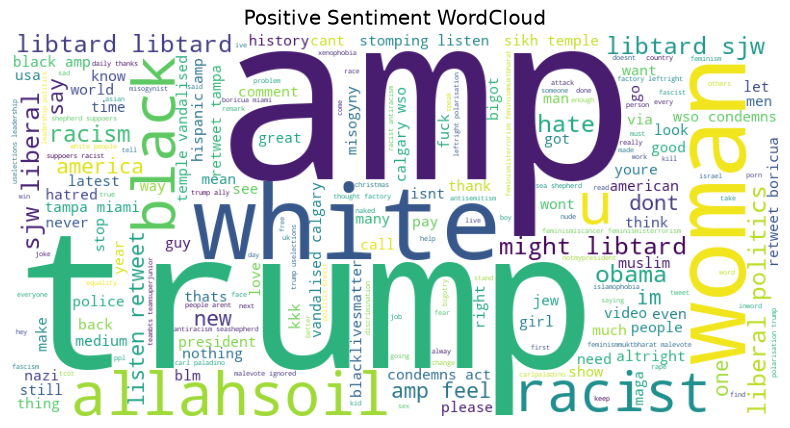

In [47]:
positive_text = " ".join(df[df["label"]==1]["clean_tweet"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Sentiment WordCloud")

plt.show()

### Observation

The WordCloud highlights the most frequently occurring words in each sentiment category.

Larger words indicate higher frequency within the corresponding sentiment class.

## Error Analysis

In [48]:
errors = pd.DataFrame({

    "Tweet":df.loc[y_test.index,"tweet"],

    "Actual":y_test,

    "Predicted":lr_pred

})

errors = errors[errors["Actual"] != errors["Predicted"]]

errors.head(5)

,Tweet,Actual,Predicted
3059,"beware the ""snowball effect"" blackman! pa 2",1,0
31765,what has todayÂs attitude to women got in com...,1,0
20064,the immature @user is just trying to make a fo...,1,0
24767,porn vids web free sex,1,0
3717,jeff sessions omits decades of records for his...,1,0


## Error Analysis

Some tweets were misclassified due to:

- Sarcasm or irony
- Ambiguous wording
- Mixed sentiments
- Lack of contextual understanding
- Informal language or slang

These limitations are common in traditional machine learning models and can be addressed using more advanced deep learning techniques.

# Business Insights

- Organizations can monitor customer opinions in real time.
- Businesses can identify dissatisfied customers and respond proactively.
- Positive customer feedback can be used for marketing campaigns.
- Product reviews can be analyzed to improve products and services.
- Sentiment analysis enables better customer engagement and data-driven decision-making.

# Conclusion

This project successfully developed a sentiment analysis model using Natural Language Processing and Machine Learning techniques.

### Key Achievements

- Cleaned and preprocessed textual data.
- Converted text into numerical features using TF-IDF.
- Trained and evaluated two classification models:
  - Naive Bayes
  - Logistic Regression
- Compared model performance using accuracy, precision, recall, F1-score, and confusion matrices.
- Visualized sentiment distributions and important words through WordClouds.
- Performed error analysis to understand model limitations.

### Final Outcome

The model with the highest evaluation metrics is considered the best-performing classifier and can be used for real-world applications such as customer feedback analysis, product review monitoring, brand reputation management, and social media sentiment tracking.